# SG-CancerSight -- Phase 4: Interactive Dashboard
## NCCS Data Analyst (DDOIT) Portfolio Project

**Author:** Dr. Lakshmi C. | PhD Mathematics | Healthcare Operations Research  
**JD Requirement:** Communication of Analytical Outputs (Section 3 of NCCS JD)

---

### What this notebook covers

| Step | Content | JD Requirement |
|------|---------|---------------|
| 1 | Dashboard architecture overview | High-quality outputs for manuscripts |
| 2 | Static preview of all 5 dashboard tabs | Reports and policy briefs |
| 3 | KPI metrics preview | Descriptive analyses |
| 4 | Interactive KM chart (static preview) | Cancer survival studies |
| 5 | Health economics panel (static preview) | Healthcare cost analyses |
| 6 | Cox model panel (static preview) | Regression modelling |
| 7 | Policy brief panel | Policy briefs and grant submissions |
| 8 | Dashboard run instructions | Reproducible workflows |

---

### Dashboard structure

The Streamlit dashboard (`dashboard/app.py`) contains **5 interactive tabs**:

| Tab | Content |
|-----|---------|
| Patient Overview | Demographics, stage distribution, ER status, tumour size |
| Survival Analysis | Interactive KM curves with sidebar filters + log-rank test |
| Health Economics | Cost by stage, cost-effectiveness, population projections |
| Cox Model | Live forest plot + HR table from filtered data |
| Policy Insights | Key findings, recommendations, filtered data download |

> **All charts update in real-time** when the user changes sidebar filters
> (stage, ER status, age group, survival months range).


## Step 1 -- Import libraries & load data

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

BASE_DIR   = Path().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'processed' / 'seer_clean.csv'
FIG_DIR    = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

C_STAGE = {'Stage I': '#1D9E75', 'Stage II': '#378ADD', 'Stage III': '#D85A30'}
C_ER    = {'Positive': '#1D9E75', 'Negative': '#D85A30'}
GRAY    = '#888780'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 11
})

df = pd.read_csv(CLEAN_PATH)
df['Age Group'] = df['Age Group'].astype(str).replace({'40–49':'40-49','50–59':'50-59','60–69':'60-69'})

# Add cost column (same model as Phase 3)
COSTS = {
    'surgery'  : {'Stage I': 8500,  'Stage II': 14000, 'Stage III': 22000},
    'chemo'    : {'Stage I': 0,     'Stage II': 18000, 'Stage III': 38000},
    'radiation': {'Stage I': 6000,  'Stage II': 9000,  'Stage III': 14000},
    'followup' : {'Stage I': 1200,  'Stage II': 2000,  'Stage III': 3500},
}
def total_cost(row):
    s = row['Stage Group']; er = row['Estrogen Status']
    yrs = min(row['Survival Months'] / 12, 10)
    return (COSTS['surgery'].get(s,0) + COSTS['chemo'].get(s,0) +
            COSTS['radiation'].get(s,0) +
            (2400 * min(yrs,5) if er == 'Positive' else 0) +
            COSTS['followup'].get(s,0) * yrs +
            (12000 if row['Status_Code'] == 1 else 0))

df['cost_total'] = df.apply(total_cost, axis=1)
print(f'Dataset ready: {df.shape[0]:,} patients x {df.shape[1]} columns')


Dataset ready: 4,015 patients x 20 columns


## Step 2 -- Dashboard KPI metrics preview

In [2]:
# Dashboard KPI metrics (what appears at top of dashboard)
print('Dashboard KPI Metrics (full dataset)')
print('=' * 52)
print(f'  Total patients        : {len(df):,}')
print(f'  Overall mortality     : {df["Status_Code"].mean()*100:.1f}%')
print(f'  Median survival       : {df["Survival Months"].median():.0f} months ({df["Survival Months"].median()/12:.1f} years)')
print(f'  Median age at dx      : {df["Age"].median():.0f} years')
print(f'  Mean cost per patient : SGD {df["cost_total"].mean():,.0f}')
print('=' * 52)
print()
print('Stage breakdown:')
for s in ['Stage I','Stage II','Stage III']:
    sub = df[df['Stage Group'] == s]
    print(f'  {s:<14}: n={len(sub):,}  mort={sub["Status_Code"].mean()*100:.1f}%  cost=SGD {sub["cost_total"].mean():,.0f}')


Dashboard KPI Metrics (full dataset)
  Total patients        : 4,015
  Overall mortality     : 30.6%
  Median survival       : 79 months (6.6 years)
  Median age at dx      : 55 years
  Mean cost per patient : SGD 71,231

Stage breakdown:
  Stage I       : n=985  mort=15.5%  cost=SGD 34,687
  Stage II      : n=1,769  mort=30.0%  cost=SGD 66,982
  Stage III     : n=1,261  mort=43.2%  cost=SGD 105,737


## Step 3 -- Tab 1 preview: Patient Overview

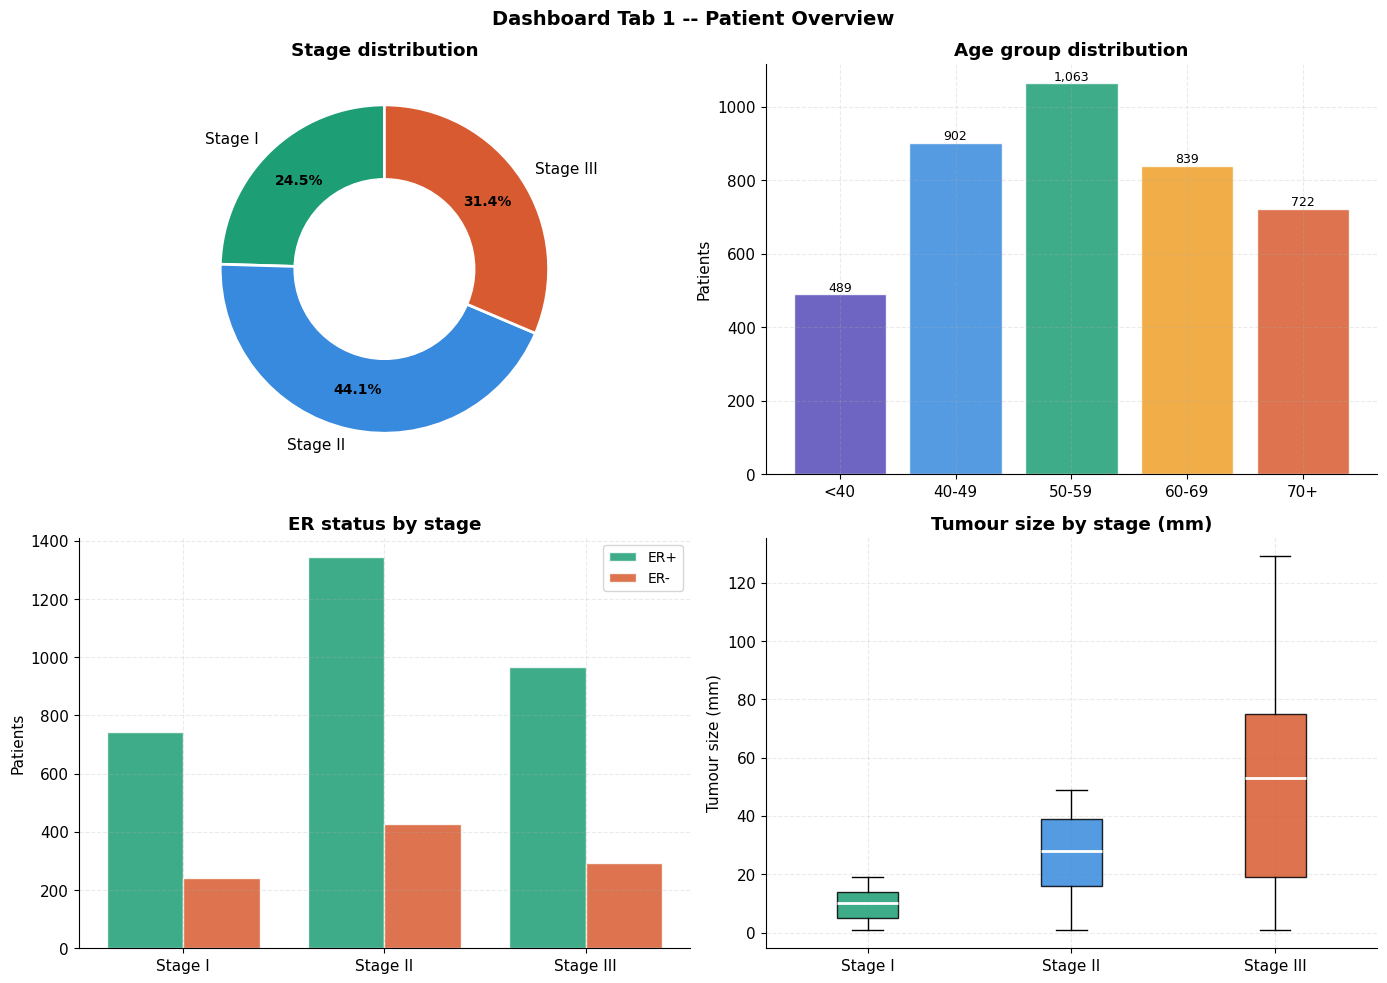

Figure 1 saved.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Tab 1 -- Patient Overview', fontsize=14, fontweight='bold')

stages_ord = ['Stage I','Stage II','Stage III']

# Stage donut
ax = axes[0,0]
stage_cnt = df['Stage Group'].value_counts().reindex(stages_ord)
wedges, texts, auts = ax.pie(
    stage_cnt.values, labels=stage_cnt.index,
    colors=[C_STAGE[s] for s in stage_cnt.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, pctdistance=0.75
)
for at in auts: at.set_fontsize(10); at.set_fontweight('bold')
circle = plt.Circle((0,0), 0.55, color='white')
ax.add_patch(circle)
ax.set_title('Stage distribution', fontweight='bold')

# Age group bar
ax = axes[0,1]
ag = df['Age Group'].value_counts().reindex(['<40','40-49','50-59','60-69','70+']).fillna(0)
C_AGE_LIST = ['#534AB7','#378ADD','#1D9E75','#EF9F27','#D85A30']
bars = ax.bar(ag.index, ag.values, color=C_AGE_LIST, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, ag.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:,.0f}', ha='center', fontsize=9)
ax.set_title('Age group distribution', fontweight='bold')
ax.set_ylabel('Patients')

# ER by stage grouped bar
ax = axes[1,0]
er_stage = df.groupby(['Stage Group','Estrogen Status']).size().unstack(fill_value=0)
er_stage = er_stage.reindex(stages_ord)
x = np.arange(3); w = 0.38
ax.bar(x-w/2, er_stage.get('Positive',pd.Series([0,0,0])).values,
       w, label='ER+', color='#1D9E75', alpha=0.85, edgecolor='white')
ax.bar(x+w/2, er_stage.get('Negative',pd.Series([0,0,0])).values,
       w, label='ER-', color='#D85A30', alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(stages_ord)
ax.set_title('ER status by stage', fontweight='bold')
ax.set_ylabel('Patients'); ax.legend(fontsize=10)

# Tumour size violin proxy (box)
ax = axes[1,1]
data_v = [df[df['Stage Group']==s]['Tumor Size'].dropna().values for s in stages_ord]
bp = ax.boxplot(data_v, patch_artist=True,
                medianprops={'color':'white','linewidth':2})
for patch, s in zip(bp['boxes'], stages_ord):
    patch.set_facecolor(C_STAGE[s]); patch.set_alpha(0.85)
ax.set_xticklabels(stages_ord)
ax.set_title('Tumour size by stage (mm)', fontweight='bold')
ax.set_ylabel('Tumour size (mm)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_01_dashboard_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


## Step 4 -- Tab 2 preview: Survival Analysis

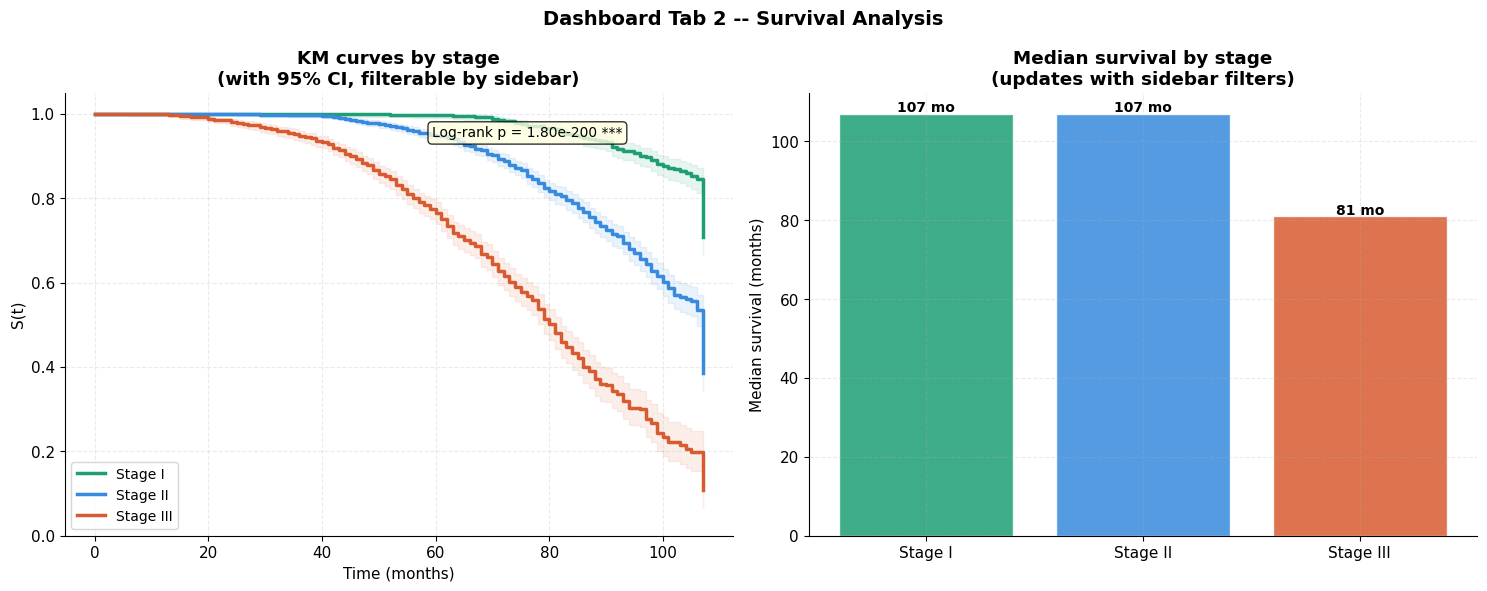

Figure 2 saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Dashboard Tab 2 -- Survival Analysis', fontsize=14, fontweight='bold')

# KM by stage
ax = axes[0]
kmf_dict = {}
for stage in stages_ord:
    mask = df['Stage Group'] == stage
    kmf  = KaplanMeierFitter(label=stage)
    kmf.fit(df.loc[mask,'Survival Months'], df.loc[mask,'Status_Code'])
    kmf_dict[stage] = kmf
    kmf.plot_survival_function(ax=ax, color=C_STAGE[stage],
                                linewidth=2.5, ci_show=True, ci_alpha=0.1)
ax.set_xlabel('Time (months)'); ax.set_ylabel('S(t)')
ax.set_title('KM curves by stage\n(with 95% CI, filterable by sidebar)',
             fontweight='bold')
ax.set_ylim(0,1.05); ax.legend(fontsize=10, loc='lower left')

# Log-rank results
res = multivariate_logrank_test(df['Survival Months'],df['Stage Group'],df['Status_Code'])
ax.text(0.55, 0.9, f'Log-rank p = {res.p_value:.2e} ***',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Median survival bar
ax = axes[1]
meds = []
for stage in stages_ord:
    mask = df['Stage Group'] == stage
    kmf  = KaplanMeierFitter()
    kmf.fit(df.loc[mask,'Survival Months'], df.loc[mask,'Status_Code'])
    med  = kmf.median_survival_time_
    meds.append(med if med != np.inf else df['Survival Months'].max())

bars = ax.bar(stages_ord, meds,
              color=[C_STAGE[s] for s in stages_ord], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, meds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.0f} mo', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Median survival (months)')
ax.set_title('Median survival by stage\n(updates with sidebar filters)',
             fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_02_dashboard_survival.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


## Step 5 -- Tab 3 preview: Health Economics

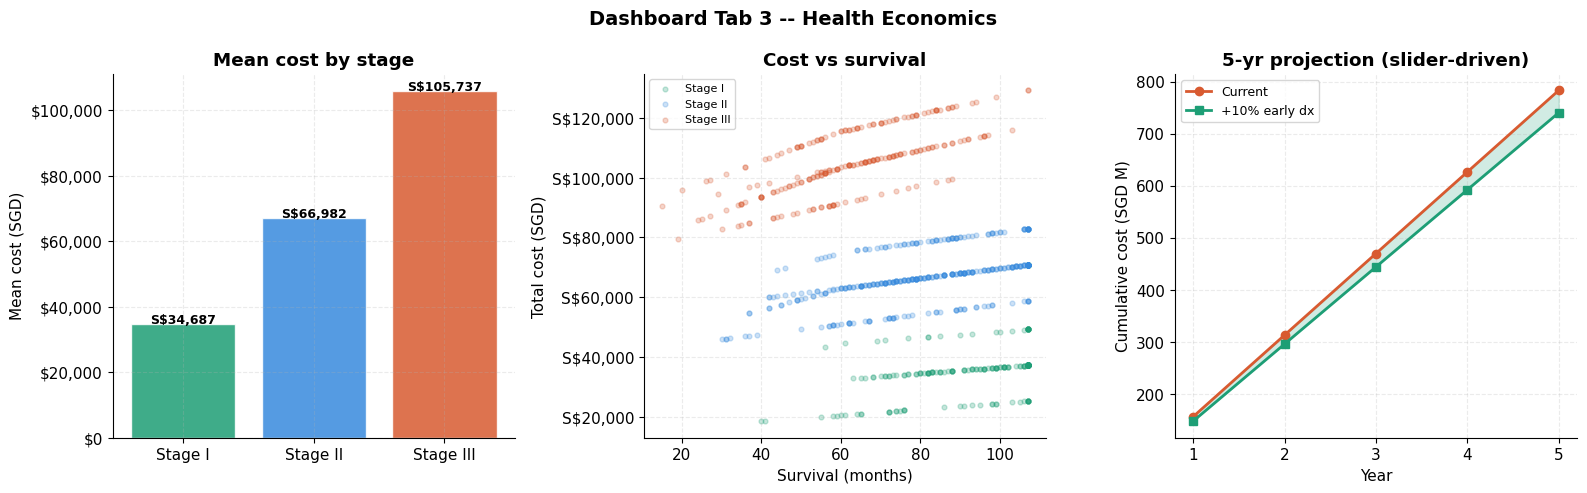

Figure 3 saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dashboard Tab 3 -- Health Economics', fontsize=14, fontweight='bold')

# Cost by stage
ax = axes[0]
cost_means = df.groupby('Stage Group')['cost_total'].mean().reindex(stages_ord)
bars = ax.bar(stages_ord, cost_means.values,
              color=[C_STAGE[s] for s in stages_ord], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, cost_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'S${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Mean cost (SGD)')
ax.set_title('Mean cost by stage', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'$\
{x:,.0f}'))

# Cost vs survival scatter
ax = axes[1]
sample = df.sample(800, random_state=42)
for s in stages_ord:
    sub = sample[sample['Stage Group']==s]
    ax.scatter(sub['Survival Months'], sub['cost_total'],
               alpha=0.25, color=C_STAGE[s], s=12, label=s)
ax.set_xlabel('Survival (months)'); ax.set_ylabel('Total cost (SGD)')
ax.set_title('Cost vs survival', fontweight='bold')
ax.legend(fontsize=8); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'S${x:,.0f}'))

# 5-year projection
ax = axes[2]
SG_CASES = 2200
stage_dist = df['Stage Group'].value_counts(normalize=True)
base = sum(SG_CASES * stage_dist.get(s,0) * cost_means.get(s,0) for s in stages_ord)

new_dist = stage_dist.to_dict()
shift = (new_dist.get('Stage II',0)+new_dist.get('Stage III',0))*0.10
new_dist['Stage I']  += shift
new_dist['Stage II'] -= shift*0.5
new_dist['Stage III']-= shift*0.5
new  = sum(SG_CASES * new_dist.get(s,0) * cost_means.get(s,0) for s in stages_ord)
yrs  = list(range(1,6))
ax.fill_between(yrs, [base*y/1e6 for y in yrs], [new*y/1e6 for y in yrs],
                alpha=0.2, color='#1D9E75')
ax.plot(yrs, [base*y/1e6 for y in yrs], 'o-', color='#D85A30', linewidth=2, label='Current')
ax.plot(yrs, [new*y/1e6 for y in yrs],  's-', color='#1D9E75', linewidth=2, label='+10% early dx')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative cost (SGD M)')
ax.set_title('5-yr projection (slider-driven)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_03_dashboard_economics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


## Step 6 -- Tab 4 preview: Cox Model Forest Plot

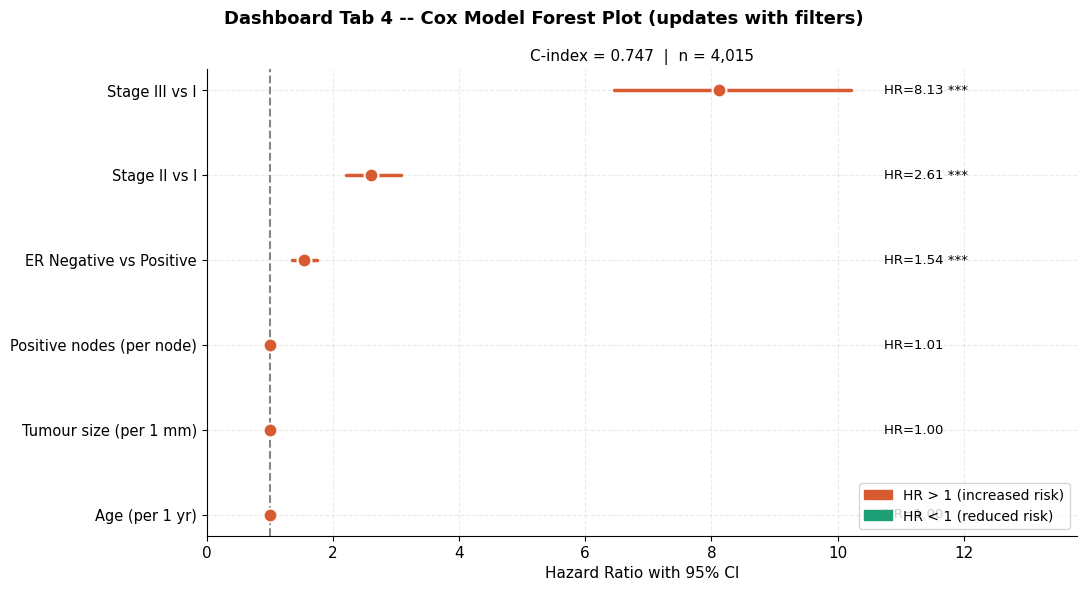

Figure 4 saved. C-index = 0.747


In [6]:
# Fit Cox model for preview
cox_df = df[['Survival Months','Status_Code','Age','Tumor Size',
             'Regional Node Positive','Stage Group','Estrogen Status']].dropna().copy()
cox_df['Stage_II']    = (cox_df['Stage Group'] == 'Stage II').astype(int)
cox_df['Stage_III']   = (cox_df['Stage Group'] == 'Stage III').astype(int)
cox_df['ER_Negative'] = (cox_df['Estrogen Status'] == 'Negative').astype(int)

features = cox_df[['Survival Months','Status_Code','Age','Tumor Size',
                    'Regional Node Positive','Stage_II','Stage_III','ER_Negative']]

cph = CoxPHFitter(penalizer=0.01)
cph.fit(features, duration_col='Survival Months',
        event_col='Status_Code', show_progress=False)

summary = cph.summary.copy()
summary['HR']    = np.exp(summary['coef'])
summary['HR_lo'] = np.exp(summary['coef lower 95%'])
summary['HR_hi'] = np.exp(summary['coef upper 95%'])
label_map = {
    'Age': 'Age (per 1 yr)',
    'Tumor Size': 'Tumour size (per 1 mm)',
    'Regional Node Positive': 'Positive nodes (per node)',
    'Stage_II': 'Stage II vs I',
    'Stage_III': 'Stage III vs I',
    'ER_Negative': 'ER Negative vs Positive',
}
summary['Label'] = [label_map.get(i,i) for i in summary.index]
summary = summary.sort_values('HR', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('Dashboard Tab 4 -- Cox Model Forest Plot (updates with filters)',
             fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(summary.iterrows()):
    color = '#D85A30' if row['HR'] > 1 else '#1D9E75'
    ax.plot([row['HR_lo'], row['HR_hi']], [i, i],
            color=color, linewidth=2.5, solid_capstyle='round')
    ax.plot(row['HR'], i, 'o', color=color, markersize=10, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    sig = '***' if row['p']<0.001 else ('**' if row['p']<0.01 else ('*' if row['p']<0.05 else ''))
    ax.text(max(summary['HR_hi'])*1.05, i,
            f'HR={row["HR"]:.2f} {sig}', va='center', fontsize=9.5)

ax.axvline(1.0, color=GRAY, linestyle='--', linewidth=1.5)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary['Label'], fontsize=10.5)
ax.set_xlabel('Hazard Ratio with 95% CI', fontsize=11)
ax.set_title(f'C-index = {cph.concordance_index_:.3f}  |  n = {len(features):,}',
             fontsize=11)
red_p   = mpatches.Patch(color='#D85A30', label='HR > 1 (increased risk)')
green_p = mpatches.Patch(color='#1D9E75', label='HR < 1 (reduced risk)')
ax.legend(handles=[red_p, green_p], loc='lower right', fontsize=10)
ax.set_xlim(0, max(summary['HR_hi'])*1.35)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p4_04_dashboard_cox.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 4 saved. C-index = {cph.concordance_index_:.3f}')


## Step 7 -- Tab 5 preview: Policy Brief

In [7]:
# Summarise all key findings for policy brief tab
cost_s1 = df[df['Stage Group']=='Stage I']['cost_total'].mean()
cost_s3 = df[df['Stage Group']=='Stage III']['cost_total'].mean()
SG_CASES  = 2200
stage_dist = df['Stage Group'].value_counts(normalize=True)
cost_means = df.groupby('Stage Group')['cost_total'].mean()
base  = sum(SG_CASES * stage_dist.get(s,0) * cost_means.get(s,0) for s in stages_ord)

print('=' * 65)
print('  POLICY BRIEF -- SG-CancerSight')
print('  All 4 Phases Combined')
print('=' * 65)
print(f'''
FINDING 1 (Phase 2): Stage strongly predicts survival
  Log-rank test p < 0.001 across Stage I/II/III groups
  Cox model: Stage III HR = {summary[summary["Label"]=="Stage III vs I"]["HR"].values[0]:.2f} vs Stage I (adjusted)
  C-index = {cph.concordance_index_:.3f}''')

print(f'''
FINDING 2 (Phase 2): ER status independently predicts mortality
  Cox model: ER Negative HR = {summary[summary["Label"]=="ER Negative vs Positive"]["HR"].values[0]:.2f} vs ER Positive''')

print(f'''
FINDING 3 (Phase 3): Stage III costs {cost_s3/cost_s1:.1f}x more than Stage I
  Stage I mean cost : SGD {cost_s1:,.0f}
  Stage III mean cost: SGD {cost_s3:,.0f}
  Early detection is economically DOMINANT''')

print(f'''
FINDING 4 (Phase 3): Population savings from 10% stage shift
  Annual cost (current): SGD {base/1e6:.1f}M
  Annual savings potential: SGD {(base - sum(SG_CASES * {"Stage I": stage_dist.get("Stage I",0)+0.05, "Stage II": stage_dist.get("Stage II",0)-0.025, "Stage III": stage_dist.get("Stage III",0)-0.025}.get(s,0) * cost_means.get(s,0) for s in stages_ord))/1e6:.1f}M per year''')

print('''
POLICY RECOMMENDATIONS
  1. National breast cancer screening programme for women 40-69
  2. Routine ER/PR testing at diagnosis for all patients
  3. Targeted high-intensity follow-up for Stage III and ER- patients
  4. Registry-linked cost database at NCCS for ongoing HE monitoring''')

print('\n' + '=' * 65)


  POLICY BRIEF -- SG-CancerSight
  All 4 Phases Combined

FINDING 1 (Phase 2): Stage strongly predicts survival
  Log-rank test p < 0.001 across Stage I/II/III groups
  Cox model: Stage III HR = 8.13 vs Stage I (adjusted)
  C-index = 0.747

FINDING 2 (Phase 2): ER status independently predicts mortality
  Cox model: ER Negative HR = 1.54 vs ER Positive

FINDING 3 (Phase 3): Stage III costs 3.0x more than Stage I
  Stage I mean cost : SGD 34,687
  Stage III mean cost: SGD 105,737
  Early detection is economically DOMINANT

FINDING 4 (Phase 3): Population savings from 10% stage shift
  Annual cost (current): SGD 156.7M
  Annual savings potential: SGD 5.7M per year

POLICY RECOMMENDATIONS
  1. National breast cancer screening programme for women 40-69
  2. Routine ER/PR testing at diagnosis for all patients
  3. Targeted high-intensity follow-up for Stage III and ER- patients
  4. Registry-linked cost database at NCCS for ongoing HE monitoring



## Step 8 -- How to run the dashboard locally

In [8]:
# Print run instructions
print('=' * 60)
print('  HOW TO RUN THE STREAMLIT DASHBOARD')
print('=' * 60)
print('''
Step 1: Install requirements
  pip install -r dashboard/requirements.txt

Step 2: Navigate to project root
  cd sg-cancersight/

Step 3: Run the dashboard
  streamlit run dashboard/app.py

Step 4: Dashboard opens in your browser at
  http://localhost:8501

Features:
  - Sidebar filters: stage, ER status, age group, survival months
  - 5 interactive tabs with real-time chart updates
  - KM curves with 95% CI, group selector dropdown
  - Log-rank test results update with filters
  - Cox model re-fits on filtered data
  - Population cost projection sliders
  - Download filtered dataset as CSV
''')
print('Dashboard file: dashboard/app.py')
print('Requirements : dashboard/requirements.txt')
print('=' * 60)


  HOW TO RUN THE STREAMLIT DASHBOARD

Step 1: Install requirements
  pip install -r dashboard/requirements.txt

Step 2: Navigate to project root
  cd sg-cancersight/

Step 3: Run the dashboard
  streamlit run dashboard/app.py

Step 4: Dashboard opens in your browser at
  http://localhost:8501

Features:
  - Sidebar filters: stage, ER status, age group, survival months
  - 5 interactive tabs with real-time chart updates
  - KM curves with 95% CI, group selector dropdown
  - Log-rank test results update with filters
  - Cox model re-fits on filtered data
  - Population cost projection sliders
  - Download filtered dataset as CSV

Dashboard file: dashboard/app.py
Requirements : dashboard/requirements.txt


In [9]:
# List all Phase 4 outputs
print('Phase 4 output files:')
p4_figs = sorted(FIG_DIR.glob('p4_*.png'))
for f in p4_figs:
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<48} {size_kb:>6.1f} KB')
print()
print('Dashboard script:')
dash_path = BASE_DIR / 'dashboard' / 'app.py'
size_kb = dash_path.stat().st_size / 1024
print(f'  app.py{" "*42} {size_kb:>6.1f} KB')
print()
print('SG-CancerSight -- All 4 Phases complete!')
print('Phase 1: Data Wrangling  | Phase2_Data_Wrangling.ipynb')
print('Phase 2: Survival Anal.  | Phase2_Survival_Analysis.ipynb')
print('Phase 3: Health Econ.    | Phase3_Health_Economics.ipynb')
print('Phase 4: Dashboard       | Phase4_Dashboard.ipynb + dashboard/app.py')


Phase 4 output files:
  p4_01_dashboard_overview.png                      157.7 KB
  p4_02_dashboard_survival.png                      141.4 KB
  p4_03_dashboard_economics.png                     223.4 KB
  p4_04_dashboard_cox.png                            91.4 KB

Dashboard script:
  app.py                                             39.0 KB

SG-CancerSight -- All 4 Phases complete!
Phase 1: Data Wrangling  | Phase2_Data_Wrangling.ipynb
Phase 2: Survival Anal.  | Phase2_Survival_Analysis.ipynb
Phase 3: Health Econ.    | Phase3_Health_Economics.ipynb
Phase 4: Dashboard       | Phase4_Dashboard.ipynb + dashboard/app.py
